 Regression

Epoch 0/400, Train Loss: 0.8510, Test Loss: 1.1765
Epoch 10/400, Train Loss: 0.4394, Test Loss: 0.6906
Epoch 20/400, Train Loss: 0.4089, Test Loss: 0.6625
Epoch 30/400, Train Loss: 0.3881, Test Loss: 0.6411
Epoch 40/400, Train Loss: 0.3530, Test Loss: 0.6487
Epoch 50/400, Train Loss: 0.3490, Test Loss: 0.6379
Epoch 60/400, Train Loss: 0.3259, Test Loss: 0.6622
Epoch 70/400, Train Loss: 0.3252, Test Loss: 0.6345
Epoch 80/400, Train Loss: 0.3000, Test Loss: 0.6561
Epoch 90/400, Train Loss: 0.3180, Test Loss: 0.6617
Epoch 100/400, Train Loss: 0.3213, Test Loss: 0.6450
Epoch 110/400, Train Loss: 0.2970, Test Loss: 0.6531
Epoch 120/400, Train Loss: 0.2965, Test Loss: 0.6076
Epoch 130/400, Train Loss: 0.2960, Test Loss: 0.6364
Epoch 140/400, Train Loss: 0.3007, Test Loss: 0.6498
Epoch 150/400, Train Loss: 0.2857, Test Loss: 0.6082
Epoch 160/400, Train Loss: 0.2744, Test Loss: 0.6551
Epoch 170/400, Train Loss: 0.2617, Test Loss: 0.6524
Epoch 180/400, Train Loss: 0.2628, Test Loss: 0.6611
Epoc

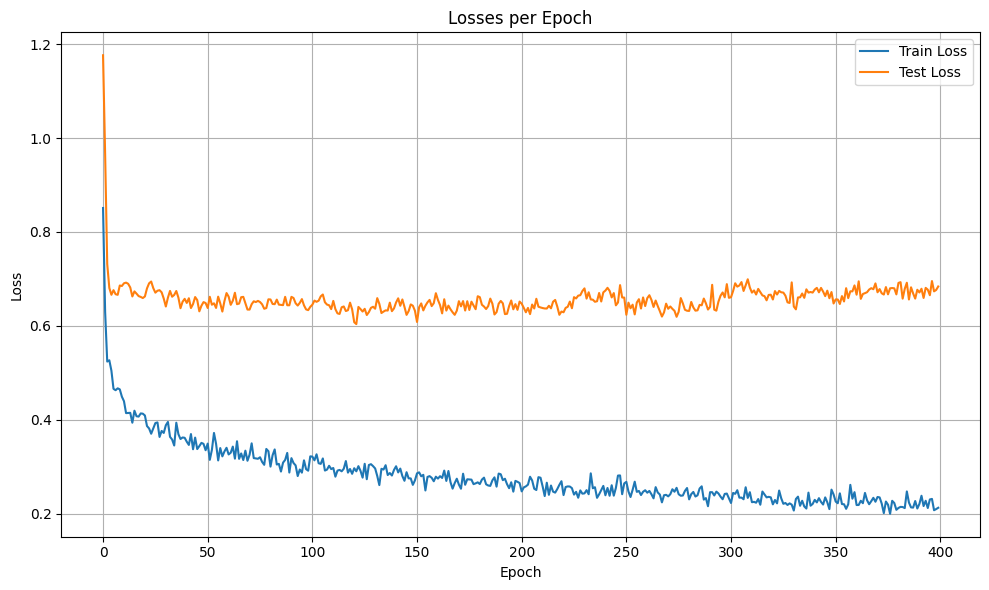


Train RMSE: 331441.29, R²: 0.9644
Test RMSE: 1409203.00, R²: 0.6071
Train Accuracy: 85.55%
Test Accuracy: 31.19%


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv("Housing.csv")

# One-Hot Encoding
df = pd.get_dummies(df, columns=["mainroad", "guestroom", "basement", "hotwaterheating",
                                 "airconditioning", "prefarea", "furnishingstatus"], dtype=int)

# Train/Test
X = df.drop(columns=["price"]).values
y = df["price"].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = RobustScaler(quantile_range=(5, 95))
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
y_train = scaler_y.fit_transform(y_train)
X_test = scaler_X.transform(X_test)
y_test = scaler_y.transform(y_test)

# Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Dataset & DataLoader
batch_size = 32
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

class HousePriceModel(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.fc(x)

model = HousePriceModel(X_train.shape[1])

# Custom Loss Function
class WeightedMAE(nn.Module):
    def __init__(self, delta=1.5):
        super().__init__()
        self.delta = delta

    def forward(self, preds, target):
        errors = torch.abs(preds - target)
        weights = torch.where(errors < self.delta,
                            1.0,
                            2.0 - torch.exp(-(errors - self.delta)))
        return torch.mean(weights * errors)

criterion = WeightedMAE(delta=1.5)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

epochs = 400
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, targets in train_loader:
        optimizer.zero_grad()
        predictions = model(inputs)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        total_test_loss = 0
        for inputs, targets in test_loader:
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            total_test_loss += loss.item()
        avg_test_loss = total_test_loss / len(test_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

# Plot Training and Test Loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Losses per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).numpy()
    y_pred_train = model(X_train_tensor).numpy()

# Undo standardization
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test)
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_train_inv = scaler_y.inverse_transform(y_pred_train)
y_train_inv = scaler_y.inverse_transform(y_train)

# RMSE և R²
rmse_test = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
rmse_train = np.sqrt(mean_squared_error(y_train_inv, y_pred_train_inv))
r2_test = r2_score(y_test_inv, y_pred_test_inv)
r2_train = r2_score(y_train_inv, y_pred_train_inv)

print(f"\nTrain RMSE: {rmse_train:.2f}, R²: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.2f}, R²: {r2_test:.4f}")

# Accuracy
def calculate_accuracy(y_true, y_pred, threshold=0.1):
    error = np.abs(y_true - y_pred)
    correct_predictions = error <= threshold * y_true
    accuracy_percentage = np.mean(correct_predictions) * 100
    return accuracy_percentage

accuracy_test = calculate_accuracy(y_test_inv, y_pred_test_inv)
accuracy_train = calculate_accuracy(y_train_inv, y_pred_train_inv)

print(f"Train Accuracy: {accuracy_train:.2f}%")
print(f"Test Accuracy: {accuracy_test:.2f}%")
